# Лаба 1: эмпирический анализ трёх LLM

Данные запуска **4 октября 2026**: Qwen 2.5 3B, Llama 3.2 3B, Gemma 3 4B, Ollama 0.35.1,
RTX 3060 Laptop 6 ГБ. Три задания, режимы A/B, по пять повторов — 90 основных ответов.

Этот ноутбук читает сохранённые результаты и **не вызывает модели**.
Исходные JSONL сохранены без изменений в gzip. `summary.csv` — исходная сводка скрипта;
таблицы ниже пересчитаны из ответов. Дополнительные native-генерации не смешиваются
с основными ответами при оценке качества.

Запуск: `uv sync --locked --group analysis`, затем открыть ноутбук в VS Code с ядром
`lab1/.venv`. Выполнить все ячейки сверху вниз. Код и пояснения находятся в одном ноутбуке.

In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations, product
import gzip
import json
import re
import statistics
import unicodedata

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'data/run_20261004/runs.jsonl.gz').exists())
DATA = ROOT / 'data/run_20261004'
metadata = json.loads((DATA / 'metadata.json').read_text(encoding='utf-8'))
with gzip.open(DATA / 'runs.jsonl.gz', 'rt', encoding='utf-8') as source:
    runs = [json.loads(line) for line in source if line.strip()]
references = {item['id']: item for item in metadata['prompts']}
models = metadata['models']
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda value: f'{value:.3f}')
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans'})
print(f"Статус: {metadata['status']}; основных ответов: {len(runs)}")

Статус: completed; основных ответов: 90


## 1. Полнота данных и условия эксперимента

Проверяем все 18 комбинаций и номера повторов, статусы обоих API, причины завершения,
наличие серверных `timings` и согласованность счётчиков токенов. Параметры A не задавались,
B одновременно меняет три параметра. Этот эксперимент показывает влияние **набора настроек**,
но не позволяет выделить эффект одной температуры или одного `top_p`.

In [2]:
rows = []
for run in runs:
    timing = next((chunk['timings'] for chunk in reversed(run['raw_chunks']) if chunk.get('timings')), {})
    metrics = run['metrics']
    generation_s = timing.get('predicted_ms', float('nan')) / 1000
    output_tokens = metrics['completion_tokens']
    native = run['native_measurement']
    rows.append({
        'model': run['model'], 'prompt': run['prompt_id'], 'mode': run['mode'], 'repeat': run['repeat'],
        'status': run['status'], 'native_status': native['status'], 'answer': run['answer'],
        'finish_reason': run['finish_reason'], 'input_tokens': metrics['prompt_tokens'],
        'output_tokens': output_tokens, 'elapsed_s': metrics['elapsed_s'], 'first_text_s': metrics['first_text_s'],
        'cached_tokens': metrics['cached_prompt_tokens'], 'generation_s': generation_s,
        'generation_tps': output_tokens / generation_s if generation_s > 0 else float('nan'),
        'prompt_eval_s': timing.get('prompt_ms', float('nan')) / 1000,
        'repetition': metrics['repeated_word_trigram_fraction'],
        'native_generation_tps': native.get('metrics', {}).get('server_generation_tokens_per_s'),
        'timing_output_tokens': timing.get('predicted_n'),
    })
df = pd.DataFrame(rows)
KEYS = ['model', 'prompt', 'mode']
expected = set(product(models, ['P1', 'P2', 'P3'], ['A', 'B'], range(1, metadata['repeats'] + 1)))
observed = set(df[['model', 'prompt', 'mode', 'repeat']].itertuples(index=False, name=None))
assert observed == expected and len(df) == len(expected) == 90
assert not df.duplicated(['model', 'prompt', 'mode', 'repeat']).any()
assert df['status'].eq('ok').all() and df['native_status'].eq('ok').all()
assert df['finish_reason'].eq('stop').all()
assert df['timing_output_tokens'].eq(df['output_tokens']).all()
assert all(not {'temperature', 'top_p', 'max_tokens'} & run['request'].keys() for run in runs if run['mode'] == 'A')
assert all(all(run['request'].get(key) == value for key, value in metadata['modes']['B'].items()) for run in runs if run['mode'] == 'B')
display(df.groupby(KEYS).agg(runs=('repeat', 'size'), errors=('status', lambda x: x.ne('ok').sum()),
                           truncated=('finish_reason', lambda x: x.eq('length').sum())))
print(metadata['nvidia_smi']['stdout'])
display(pd.DataFrame([{'model': model, 'model_parameters': details.get('parameters', 'Нет переопределений в модели'),
                      'digest': next(item['digest'] for item in metadata['ollama_models']['models'] if item['name'] == model)}
                     for model, details in metadata['model_details'].items()]))
print('A:', metadata['modes']['A'], '\nB:', metadata['modes']['B'])

name, driver_version, memory.total [MiB], memory.used [MiB], power.limit [W]
NVIDIA GeForce RTX 3060 Laptop GPU, 581.80, 6144 MiB, 0 MiB, [N/A]
A: {} 
B: {'temperature': 0.2, 'top_p': 0.8, 'max_tokens': 512}


runs  errors  truncated
model       prompt mode                         
gemma3:4b   P1     A        5       0          0
                   B        5       0          0
            P2     A        5       0          0
                   B        5       0          0
            P3     A        5       0          0
                   B        5       0          0
llama3.2:3b P1     A        5       0          0
                   B        5       0          0
            P2     A        5       0          0
                   B        5       0          0
            P3     A        5       0          0
                   B        5       0          0
qwen2.5:3b  P1     A        5       0          0
                   B        5       0          0
            P2     A        5       0          0
                   B        5       0          0
            P3     A        5       0          0
                   B        5       0          0

,model,model_parameters,digest
0,qwen2.5:3b,Нет переопределений в модели,357c53fb659c5076de1d65ccb0b397446227b71a42be9d...
1,llama3.2:3b,"stop ""<|start_header...",a80c4f17acd55265feec403c7aef86be0c25983ab279d8...
2,gemma3:4b,"stop ""<end_of_turn>""...",a2af6cc3eb7fa8be8504abaf9b04e88f17a119ec3f04a3...


Для Qwen и Llama `/api/show` не содержит всех глобальных дефолтов движка.
Поэтому полный набор эффективных значений A нельзя восстановить только из этих метаданных.
Подтверждено отсутствие клиентских переопределений. У Gemma сохранены `temperature=1`,
`top_p=0.95`, `top_k=64`; в B заданы 0.2, 0.8 и лимит 512 токенов.
Ни один ответ не завершился по лимиту длины, поэтому действие `max_tokens` здесь не наблюдалось.

## 2. Длина, время отклика и скорость генерации

Серверная скорость основного ответа вычисляется из его собственного
`timings.predicted_n / (timings.predicted_ms / 1000)`. Это уточнение к скрипту запуска:
поля в `metrics` оставлены пустыми, но сырые `timings` сохранены у всех 90 ответов.
Время до первого текста измерено на клиенте, а не внутри движка.

Показываем среднее, стандартное отклонение и медиану. Среднее чувствительно к первому
некэшированному запросу. Разное число токенов у разных моделей связано также с разными
токенизаторами: токены/с не равны скорости выдачи одинакового объёма русского текста.

tokens_mean  tokens_std  latency_mean_s  \
model       prompt mode                                            
gemma3:4b   P1     A         131.200       6.181           3.089   
                   B         119.000       1.225           1.471   
            P2     A          59.000       0.000           0.768   
                   B          59.000       0.000           0.760   
            P3     A          75.600       2.074           0.960   
                   B          79.000       0.000           0.991   
llama3.2:3b P1     A         123.600      43.259           1.166   
                   B         122.600      21.420           1.141   
            P2     A          39.400       0.894           0.456   
                   B          39.000       0.000           0.439   
            P3     A          48.800       4.658           0.467   
                   B          58.000       1.000           0.537   
qwen2.5:3b  P1     A          84.200      12.755           0.776   
                   B          81.600       5.727           0.741   
            P2     A          33.800       7.430           0.329   
                   B          37.400       8.764           0.357   
            P3     A          60.400       1.517           0.566   
                   B          61.000       0.000           0.559   

                         latency_median_s  latency_std_s  first_text_mean_s  \
model       prompt mode                                                       
gemma3:4b   P1     A                1.667          3.326              1.539   
                   B                1.476          0.024              0.070   
            P2     A                0.773          0.023              0.074   
                   B                0.756          0.012              0.063   
            P3     A                0.948          0.032              0.068   
                   B                0.989          0.005              0.057   
llama3.2:3b P1     A                1.194          0.388              0.051   
                   B                1.232          0.203              0.021   
            P2     A                0.421          0.111              0.031   
                   B                0.372          0.101              0.020   
            P3     A                0.445          0.048              0.030   
                   B                0.535          0.011              0.019   
qwen2.5:3b  P1     A                0.833          0.124              0.030   
                   B                0.771          0.054              0.018   
            P2     A                0.293          0.061              0.032   
                   B                0.324          0.075              0.020   
            P3     A                0.562          0.010              0.029   
                   B                0.560          0.004              0.019   

                         generation_tps_mean  generation_tps_std  \
model       prompt mode                                            
gemma3:4b   P1     A                  84.698               0.441   
                   B                  84.956               0.624   
            P2     A                  85.057               1.374   
                   B                  84.778               0.921   
            P3     A                  84.808               0.248   
                   B                  84.637               0.219   
llama3.2:3b P1     A                 109.048               3.862   
                   B                 109.656               2.585   
            P2     A                  98.063              23.153   
                   B                  97.436              21.317   
            P3     A                 111.822               1.195   
                   B                 112.191               0.358   
qwen2.5:3b  P1     A                 112.909               0.674   
                   B                 112.922               0.72

latency_mean_s  latency_median_s  generation_tps_mean  \
model       mode                                                          
gemma3:4b   A              1.606             0.948               84.854   
            B              1.074             0.989               84.790   
llama3.2:3b A              0.696             0.526              106.311   
            B              0.705             0.548              106.428   
qwen2.5:3b  A              0.557             0.562              113.134   
            B              0.552             0.560              112.457   

                  output_tokens_mean  
model       mode                      
gemma3:4b   A                 88.600  
            B                 85.667  
llama3.2:3b A                 70.600  
            B                 73.200  
qwen2.5:3b  A                 59.467  
            B                 60.000

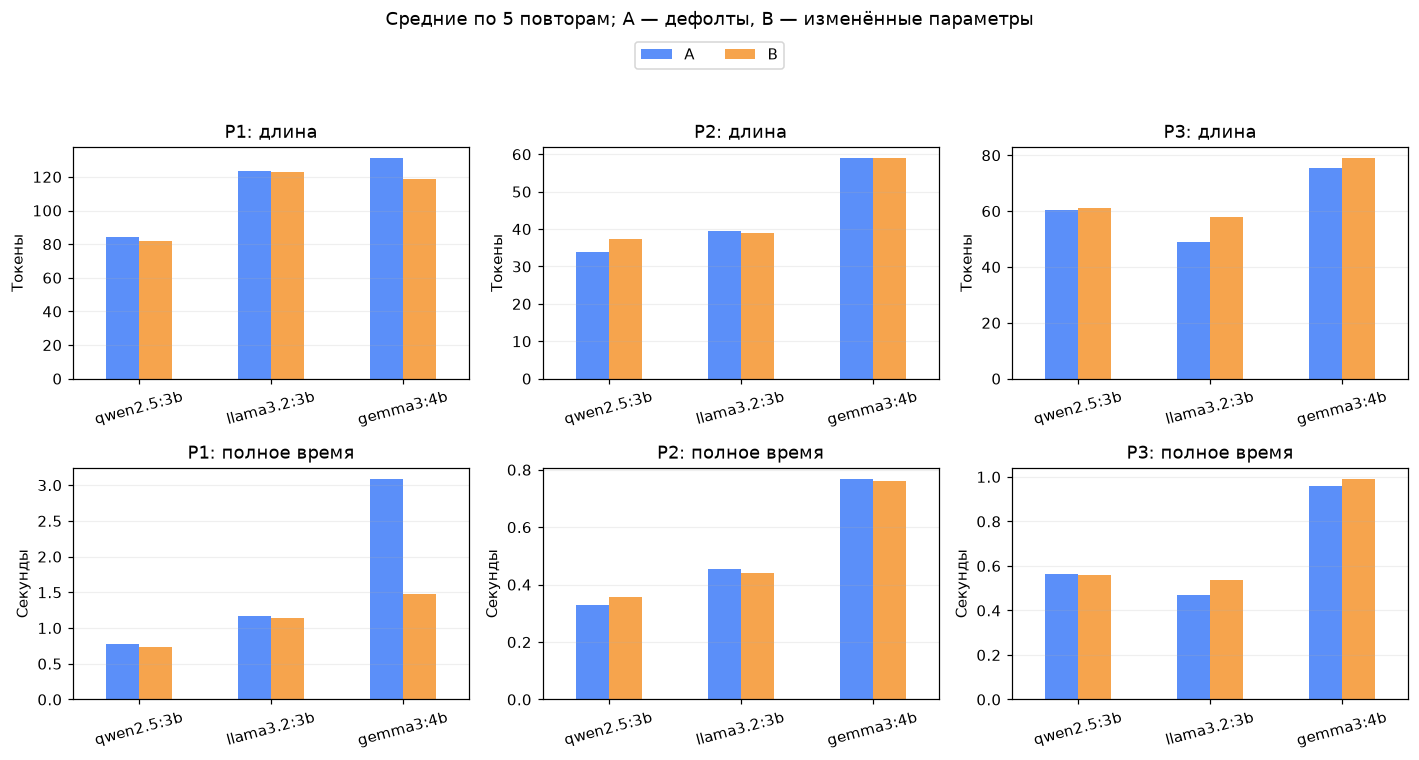

In [3]:
performance = df.groupby(KEYS).agg(
    tokens_mean=('output_tokens', 'mean'), tokens_std=('output_tokens', 'std'),
    latency_mean_s=('elapsed_s', 'mean'), latency_median_s=('elapsed_s', 'median'), latency_std_s=('elapsed_s', 'std'),
    first_text_mean_s=('first_text_s', 'mean'),
    generation_tps_mean=('generation_tps', 'mean'), generation_tps_std=('generation_tps', 'std'),
    generation_mean_s=('generation_s', 'mean'),
)
display(performance)
display(df.groupby(['model', 'mode']).agg(
    latency_mean_s=('elapsed_s', 'mean'), latency_median_s=('elapsed_s', 'median'),
    generation_tps_mean=('generation_tps', 'mean'), output_tokens_mean=('output_tokens', 'mean')))
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for column, prompt in enumerate(['P1', 'P2', 'P3']):
    for row, metric in enumerate(['output_tokens', 'elapsed_s']):
        values = df[df['prompt'].eq(prompt)].groupby(['model', 'mode'])[metric].mean().unstack().reindex(models)
        values.plot.bar(ax=axes[row, column], color=['#5b8ff9', '#f6a44d'], rot=15, legend=False)
        axes[row, column].set_title(f'{prompt}: ' + ('длина' if row == 0 else 'полное время'))
        axes[row, column].set_ylabel('Токены' if row == 0 else 'Секунды')
        axes[row, column].set_xlabel('')
        axes[row, column].grid(axis='y', alpha=0.2)
fig.suptitle('Средние по 5 повторам; A — дефолты, B — изменённые параметры')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2)
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

## 3. Кэш и выбросы времени

Кэш не очищался. Повторный промпт может почти целиком находиться в памяти.
Поэтому огромные значения `prompt_per_second` нельзя трактовать как скорость обработки
полностью нового входа. Дополнительные native-запросы также влияли на состояние кэша.
Покажем все наблюдения и отдельно медианы; выбросы из исходных данных не удаляем.

Сумма времени основных HTTP-генераций: 77.86 с
Сумма времени дополнительных HTTP-генераций: 69.88 с


cache_mean  prompt_eval_mean_s  latency_median_s
model       prompt mode                                                  
gemma3:4b   P1     A          0.768               1.510             1.667
                   B          0.960               0.046             1.476
            P2     A          0.778               0.060             0.773
                   B          0.972               0.054             0.756
            P3     A          0.774               0.055             0.948
                   B          0.967               0.049             0.989
llama3.2:3b P1     A          0.821               0.018             1.194
                   B          0.993               0.010             1.232
            P2     A          0.815               0.019             0.421
                   B          0.995               0.011             0.372
            P3     A          0.818               0.016             0.445
                   B          0.994               0.009             0.535
qwen2.5:3b  P1     A          0.824               0.016             0.833
                   B          0.994               0.009             0.771
            P2     A          0.817               0.020             0.293
                   B          0.996               0.011             0.324
            P3     A          0.821               0.018             0.562
                   B          0.995               0.009             0.560

,model,prompt,mode,repeat,elapsed_s,first_text_s,prompt_eval_s,generation_s,cached_tokens,input_tokens
60,gemma3:4b,P1,A,1,9.038,7.410,7.374,1.627,0,125
63,gemma3:4b,P1,A,2,1.668,0.080,0.045,1.587,120,125
64,gemma3:4b,P1,A,3,1.667,0.082,0.043,1.585,120,125
30,llama3.2:3b,P1,A,1,1.652,0.073,0.050,1.579,20,150
68,gemma3:4b,P1,A,5,1.558,0.074,0.043,1.483,120,125


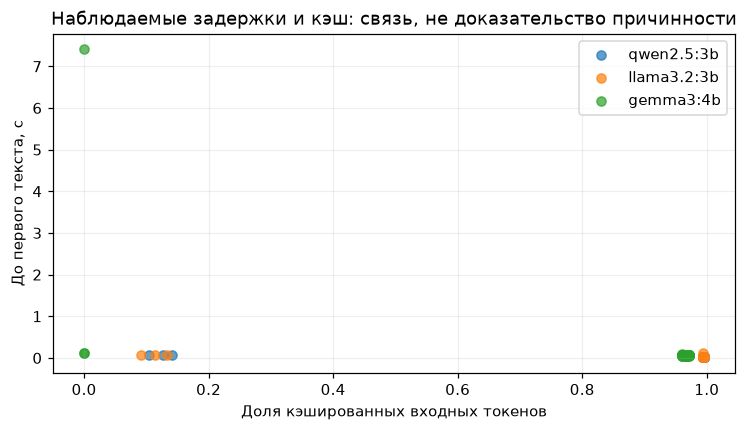

In [4]:
df['cached_fraction'] = df['cached_tokens'] / df['input_tokens']
display(df.groupby(KEYS).agg(cache_mean=('cached_fraction', 'mean'),
                           prompt_eval_mean_s=('prompt_eval_s', 'mean'),
                           latency_median_s=('elapsed_s', 'median')))
display(df.nlargest(5, 'elapsed_s')[KEYS + ['repeat', 'elapsed_s', 'first_text_s', 'prompt_eval_s',
                                           'generation_s', 'cached_tokens', 'input_tokens']])
fig, ax = plt.subplots(figsize=(8, 4))
for model in models:
    part = df[df['model'].eq(model)]
    ax.scatter(part['cached_fraction'], part['first_text_s'], label=model, alpha=0.7)
ax.set(xlabel='Доля кэшированных входных токенов', ylabel='До первого текста, с',
       title='Наблюдаемые задержки и кэш: связь, не доказательство причинности')
ax.legend(); ax.grid(alpha=0.2); plt.show()
print('Сумма времени основных HTTP-генераций:', round(df['elapsed_s'].sum(), 2), 'с')
print('Сумма времени дополнительных HTTP-генераций:', round(sum(r['native_measurement']['elapsed_s'] for r in runs), 2), 'с')

**Gemma, P1/A/1:** полное время около 9.04 с, серверная обработка входа 7.374 с,
генерация 1.627 с, кэш 0 из 125 токенов. Причина повышенного времени обработки по
этим данным не устанавливается. Этот запрос сильно увеличивает среднее режима A.
Нельзя объявлять B быстрее из-за гиперпараметров, опираясь только на среднее полное время.

## 4. Токенизация: отдельное измерение

Сырой промпт без шаблона диалога и специальных токенов. Один прогрев и 20 замеров
внутреннего `/tokenize` загруженной модели. Время включает HTTP и разбор JSON, поэтому
это производительность сервиса токенизации, а не изолированное вычисление на процессоре.
Длительность измерения меньше двух миллисекунд: служебные задержки существенны.
Тест один на модель/промпт, не отдельный для A/B.

,model,prompt,raw_tokens,http_median_ms,http_min_ms,http_max_ms,service_tokens_per_s
0,qwen2.5:3b,P1,141,0.711,0.645,1.105,198256.467
1,qwen2.5:3b,P2,201,0.939,0.858,1.270,214011.927
2,qwen2.5:3b,P3,161,0.845,0.779,1.072,190487.458
3,llama3.2:3b,P1,125,0.686,0.644,0.962,182255.592
4,llama3.2:3b,P2,193,0.874,0.835,1.300,220836.427
5,llama3.2:3b,P3,151,1.362,0.864,3.245,110866.372
6,gemma3:4b,P1,115,0.645,0.576,0.974,178197.870
7,gemma3:4b,P2,168,0.881,0.763,1.418,190584.234
8,gemma3:4b,P3,141,0.768,0.706,4.453,183713.349


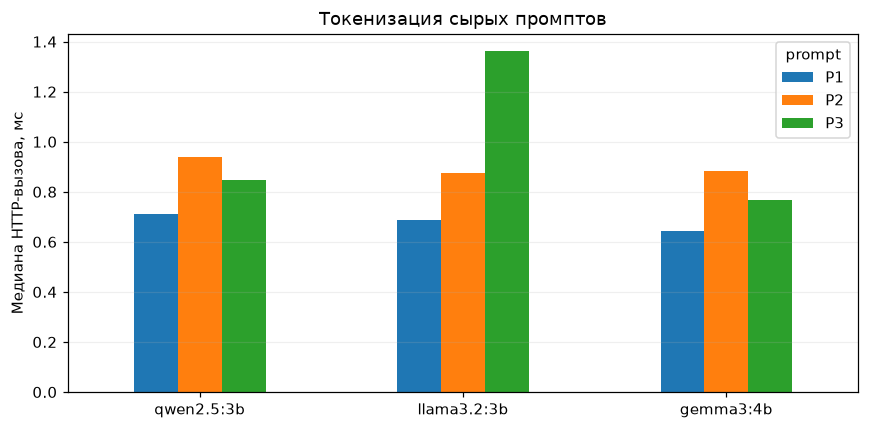

In [5]:
tokenizer_rows = []
for model, prompts in metadata['tokenization_benchmarks'].items():
    for prompt, benchmark in prompts.items():
        assert benchmark['status'] == 'ok' and len(benchmark['samples_s']) == 20
        tokenizer_rows.append({'model': model, 'prompt': prompt, 'raw_tokens': benchmark['token_count'],
            'http_median_ms': 1000 * statistics.median(benchmark['samples_s']),
            'http_min_ms': 1000 * min(benchmark['samples_s']),
            'http_max_ms': 1000 * max(benchmark['samples_s']),
            'service_tokens_per_s': benchmark['tokenization_tokens_per_s']})
tokenizer_df = pd.DataFrame(tokenizer_rows)
display(tokenizer_df)
fig, ax = plt.subplots(figsize=(8, 4))
tokenizer_df.pivot(index='model', columns='prompt', values='http_median_ms').reindex(models).plot.bar(ax=ax, rot=0)
ax.set(ylabel='Медиана HTTP-вызова, мс', xlabel='', title='Токенизация сырых промптов')
ax.grid(axis='y', alpha=0.2); plt.tight_layout(); plt.show()

## 5. Качество P2/P3: формат и смысл

**Строгое выполнение:** сырой ответ должен быть JSON-объектом с нужными ключами и
типами. Markdown запрещён промптом и считается нарушением формата.
**Смысл отдельно:** разрешаем снять только внешнюю Markdown-обёртку. Для P2 допускаем
список из шести меток или нумерованные строки, чтобы не путать правильную классификацию
с форматом. Неполные/нечитаемые ответы не исправляем и считаем нулевым результатом.

P3: `ё/е`, падеж/число чёрного цвета и перевод `black` семантически равнозначны.
Для названия разрешён явно заданный набор вариантов с типом товара и кавычками.
Это не ошибки фактов; точное строковое совпадение показываем отдельно.
Числа должны оставаться числами, `null` — отсутствующим значением.
Некорректный JSON не восстанавливаем, даже если часть полей можно угадать.

In [6]:
def parse_json(text):
    try:
        return json.loads(text)
    except (json.JSONDecodeError, TypeError):
        return None

def unfence(text):
    match = re.fullmatch(r'\s*```(?:json)?\s*\n?(.*?)\n?```\s*', text, re.S | re.I)
    return match.group(1).strip() if match else text.strip()

def classification_content(text):
    cleaned = unfence(text)
    value = parse_json(cleaned)
    if isinstance(value, dict):
        return value
    if isinstance(value, list) and len(value) == 6:
        return {str(index): label for index, label in enumerate(value, 1)}
    matches = re.findall(r'^\s*([1-6])[.)]\s*(Billing|Tech support|Sales)\s*$', cleaned, re.M)
    if len(matches) == 6 and len({key for key, _ in matches}) == 6:
        return dict(matches)
    return None

def normalized(value):
    return unicodedata.normalize('NFKC', value).strip().casefold().replace('ё', 'е')

def field_correct(key, value, expected):
    if expected is None:
        return value is None
    if isinstance(expected, (int, float)):
        return type(value) in (int, float) and value == expected
    if not isinstance(value, str):
        return False
    value = normalized(value)
    if key == 'color':
        return value in {'черный', 'черного', 'черные', 'black'}
    if key == 'name':
        return value in {'вектор а2', '«вектор а2»', 'наушники «вектор а2»',
                         'беспроводные наушники \'вектор а2\''}
    return value == normalized(expected)

quality_rows = []
for row in df[df['prompt'].isin(['P2', 'P3'])].to_dict('records'):
    expected = references[row['prompt']]['expected']
    strict = parse_json(row['answer'])
    structured = isinstance(strict, dict) and set(strict) == set(expected)
    semantic = classification_content(row['answer']) if row['prompt'] == 'P2' else parse_json(unfence(row['answer']))
    available = isinstance(semantic, dict)
    if row['prompt'] == 'P2':
        correct = [available and semantic.get(key) == value for key, value in expected.items()]
        type_ok = structured and all(isinstance(strict[key], str) for key in expected)
    else:
        correct = [available and key in semantic and field_correct(key, semantic[key], value) for key, value in expected.items()]
        type_ok = structured and all(
            strict[key] is None if value is None else
            type(strict[key]) in (int, float) if isinstance(value, (int, float)) else
            isinstance(strict[key], str) for key, value in expected.items())
    quality_rows.append({**{key: row[key] for key in KEYS + ['repeat']},
        'raw_json_object': structured, 'schema_ok': bool(type_ok),
        'exact_object': structured and strict == expected,
        'semantic_accuracy': sum(correct) / len(expected),
        'semantic_all_correct': all(correct),
        'semantic_and_format_ok': bool(type_ok) and all(correct),
        'semantic_parse_available': available})
quality_df = pd.DataFrame(quality_rows)
quality_table = quality_df.groupby(KEYS).agg(
    n=('repeat', 'size'), json_object_rate=('raw_json_object', 'mean'),
    schema_rate=('schema_ok', 'mean'), exact_object_rate=('exact_object', 'mean'),
    semantic_accuracy=('semantic_accuracy', 'mean'),
    semantic_all_rate=('semantic_all_correct', 'mean'),
    complete_success_rate=('semantic_and_format_ok', 'mean'))
display(quality_table)
for prompt in ['P2', 'P3']:
    subset = quality_df[quality_df['prompt'].eq(prompt)].groupby(['model', 'mode'])[['schema_ok', 'semantic_all_correct', 'semantic_and_format_ok']].mean()
    display(Markdown(f'**{prompt}: доля корректных ответов по разным критериям**'))
    display(subset)
# Проверки не дают мягкому разбору незаметно превратиться в строгую оценку.
assert parse_json('```json\n{"1":"Billing"}\n```') is None
assert classification_content('["Billing","Tech support","Sales","Billing","Tech support","Sales"]') == references['P2']['expected']
assert not field_correct('price_rub', '3490', 3490)
assert not field_correct('warranty_months', 12, None)
assert not field_correct('color', 'čёрный', 'чёрный')

n  json_object_rate  schema_rate  exact_object_rate  \
model       prompt mode                                                        
gemma3:4b   P2     A     5             0.000        0.000              0.000   
                   B     5             0.000        0.000              0.000   
            P3     A     5             0.000        0.000              0.000   
                   B     5             0.000        0.000              0.000   
llama3.2:3b P2     A     5             1.000        1.000              1.000   
                   B     5             1.000        1.000              1.000   
            P3     A     5             0.600        0.600              0.000   
                   B     5             0.000        0.000              0.000   
qwen2.5:3b  P2     A     5             0.200        0.200              0.200   
                   B     5             0.400        0.400              0.400   
            P3     A     5             1.000        0.800              0.400   
                   B     5             1.000        1.000              1.000   

                         semantic_accuracy  semantic_all_rate  \
model       prompt mode                                         
gemma3:4b   P2     A                 1.000              1.000   
                   B                 1.000              1.000   
            P3     A                 1.000              1.000   
                   B                 1.000              1.000   
llama3.2:3b P2     A                 1.000              1.000   
                   B                 1.000              1.000   
            P3     A                 0.800              0.800   
                   B                 1.000              1.000   
qwen2.5:3b  P2     A                 1.000              1.000   
                   B                 1.000              1.000   
            P3     A                 0.967              0.800   
                   B                 1.000              1.000   

                         complete_success_rate  
model       prompt mode                         
gemma3:4b   P2     A                     0.000  
                   B                     0.000  
            P3     A                     0.000  
                   B                     0.000  
llama3.2:3b P2     A                     1.000  
                   B                     1.000  
            P3     A                     0.600  
                   B                     0.000  
qwen2.5:3b  P2     A                     0.200  
                   B                     0.400  
            P3     A                     0.800  
                   B                     1.000

**P2: доля корректных ответов по разным критериям**

schema_ok  semantic_all_correct  semantic_and_format_ok
model       mode                                                         
gemma3:4b   A         0.000                 1.000                   0.000
            B         0.000                 1.000                   0.000
llama3.2:3b A         1.000                 1.000                   1.000
            B         1.000                 1.000                   1.000
qwen2.5:3b  A         0.200                 1.000                   0.200
            B         0.400                 1.000                   0.400

**P3: доля корректных ответов по разным критериям**

schema_ok  semantic_all_correct  semantic_and_format_ok
model       mode                                                         
gemma3:4b   A         0.000                 1.000                   0.000
            B         0.000                 1.000                   0.000
llama3.2:3b A         0.600                 0.800                   0.600
            B         0.000                 1.000                   0.000
qwen2.5:3b  A         0.800                 0.800                   0.800
            B         1.000                 1.000                   1.000

## 6. Качество P1: ограничения и ручная проверка

Слова считаются регулярным выражением: время `14:00` — одно слово, числа учитываются;
пунктуация не считается. Это уточнение к `answer_words` исходного скрипта, где двоеточие
делило время на два элемента. При пограничной длине иной способ подсчёта может изменить оценку.

Каждое из 30 писем прочитано ассистентом; проверка сохранена в `p1_review.csv` и доступна для пересмотра.
Оцениваем русский язык без иностранных вставок, сохранение основных фактов, адресата,
подпись, явные ошибки фактов и явно добавленные утверждения. Дополнительно проверяем
60–90 слов. Полное соблюдение этих критериев не является автоматической оценкой красоты
стиля или идеальной грамматики. Правдоподобные уточнения Gemma отмечены в замечаниях,
но не объявлены установленными галлюцинациями.

In [7]:
review = pd.read_csv(DATA / 'p1_review.csv', keep_default_na=False)
bool_columns = ['russian_only', 'required_facts', 'recipient_ok', 'signature_ok', 'factual_error', 'unsupported_addition']
for column in bool_columns:
    review[column] = review[column].astype(str).str.lower().eq('true')
letters = df[df['prompt'].eq('P1')].merge(review, on=['model', 'mode', 'repeat'], validate='one_to_one')
assert len(letters) == 30
letters['words'] = letters['answer'].map(lambda text: len(re.findall(r'\d{1,2}:\d{2}|[^\W_]+(?:[-’\'][^\W_]+)*', text)))
letters['length_ok'] = letters['words'].between(60, 90)
letters['criteria_ok'] = letters[['russian_only', 'required_facts', 'recipient_ok', 'signature_ok', 'length_ok']].all(axis=1) & ~letters['factual_error'] & ~letters['unsupported_addition']
letter_table = letters.groupby(['model', 'mode']).agg(
    word_mean=('words', 'mean'), word_min=('words', 'min'), word_max=('words', 'max'),
    length_rate=('length_ok', 'mean'), russian_rate=('russian_only', 'mean'),
    facts_rate=('required_facts', 'mean'), factual_errors=('factual_error', 'sum'),
    unsupported_additions=('unsupported_addition', 'sum'), criteria_rate=('criteria_ok', 'mean'))
display(letter_table)
display(letters[['model', 'mode', 'repeat', 'words', 'russian_only', 'required_facts', 'criteria_ok', 'note']])

word_mean  word_min  word_max  length_rate  russian_rate  \
model       mode                                                             
gemma3:4b   A        63.400        59        67        0.800         1.000   
            B        58.400        57        61        0.200         1.000   
llama3.2:3b A        55.000        31        82        0.400         0.000   
            B        61.200        43        72        0.600         0.800   
qwen2.5:3b  A        31.200        10        40        0.000         0.600   
            B        30.600        27        33        0.000         1.000   

                  facts_rate  factual_errors  unsupported_additions  \
model       mode                                                      
gemma3:4b   A          1.000               0                      0   
            B          1.000               0                      0   
llama3.2:3b A          0.600               1                      2   
            B          1.000               0                      0   
qwen2.5:3b  A          1.000               0                      0   
            B          1.000               0                      0   

                  criteria_rate  
model       mode                 
gemma3:4b   A             0.800  
            B             0.200  
llama3.2:3b A             0.000  
            B             0.400  
qwen2.5:3b  A             0.000  
            B             0.000

,model,mode,repeat,words,russian_only,required_facts,criteria_ok,note
0,qwen2.5:3b,A,1,38,True,True,False,Нет обращения к Марии; грамматическая ошибка «...
1,qwen2.5:3b,B,1,27,True,True,False,
2,qwen2.5:3b,B,2,32,True,True,False,
3,qwen2.5:3b,A,2,40,False,True,False,Смешанное приветствие «Дear Maria».
4,qwen2.5:3b,A,3,10,False,True,False,Письмо преимущественно на китайском; даты и пр...
5,qwen2.5:3b,B,3,33,True,True,False,
6,qwen2.5:3b,B,4,28,True,True,False,
7,qwen2.5:3b,A,4,30,True,True,False,
8,qwen2.5:3b,A,5,38,True,True,False,Причина переформулирована как «не оформлен к с...
9,qwen2.5:3b,B,5,33,True,True,False,


## 7. Устойчивость и повторяемость

Сравниваем полное совпадение текста и совпадение нормализованного результата. Для письма
нормализуются только пробелы: это не оценка смысловой эквивалентности. Для P2/P3 применяются
ровно описанные выше правила разбора. Доля совпадающих пар оценивается по 10 парам из пяти
ответов; пары зависимы. Пять совпадений не доказывают детерминизм, seed не фиксировался.
Повторные тройки слов — отдельная характеристика избыточности внутри ответа.

In [8]:
def canonical_answer(prompt, text):
    value = classification_content(text) if prompt == 'P2' else parse_json(unfence(text)) if prompt == 'P3' else None
    if prompt == 'P3' and isinstance(value, dict):
        value = value.copy()
        for key in ('name', 'color'):
            if key in value and field_correct(key, value[key], references[prompt]['expected'][key]):
                value[key] = references[prompt]['expected'][key]
    if isinstance(value, dict):
        return json.dumps(value, sort_keys=True, ensure_ascii=False)
    return re.sub(r'\s+', ' ', text).strip()

stability_rows = []
for key, group in df.groupby(KEYS, sort=False):
    answers = group['answer'].tolist()
    canonical = [canonical_answer(key[1], text) for text in answers]
    pairs = list(combinations(canonical, 2))
    stability_rows.append(dict(zip(KEYS, key)) | {
        'unique_texts': len(set(answers)), 'unique_normalized_results': len(set(canonical)),
        'largest_text_fraction': max(Counter(answers).values()) / len(answers),
        'normalized_pair_agreement': sum(a == b for a, b in pairs) / len(pairs),
        'repeated_trigrams_mean': group['repetition'].mean()})
stability_df = pd.DataFrame(stability_rows)
display(stability_df)
# Все ответы сохранены, этот помощник удобен для проверки отдельных выводов.
def show_answer(model, prompt, mode, repeat):
    answer = df[(df['model'] == model) & (df['prompt'] == prompt) & (df['mode'] == mode) & (df['repeat'] == repeat)].iloc[0]['answer']
    print(f'{model} / {prompt} / {mode} / #{repeat}\n\n{answer}')
show_answer('llama3.2:3b', 'P1', 'A', 2)
show_answer('qwen2.5:3b', 'P3', 'A', 1)
show_answer('gemma3:4b', 'P2', 'B', 1)

llama3.2:3b / P1 / A / #2

Приветstu Марии,

Уважаемая коллега,

Я обращаюсь к вам с прощальной и разъясňingly вопросом. К сожалению, из-за неполной готовности отчета по проекту "Атлас", нам нужно несколько изменить встречу. Нам нужно перенести встречу с 12 октября, 14:00 в 14 октября, 11:00. Важно, чтобы это новое время подтвердило бы, чтобы все было на ordenе. 

С удовлетворением,
Артём.
qwen2.5:3b / P3 / A / #1

{
  "name": "Вектор А2",
  "price_rub": 3490,
  "weight_g": 180,
  "battery_hours": null,
  "color": "черные",
  "warranty_months": null
}
gemma3:4b / P2 / B / #1

```json
{
  "1": "Billing",
  "2": "Tech support",
  "3": "Sales",
  "4": "Billing",
  "5": "Tech support",
  "6": "Sales"
}
```


,model,prompt,mode,unique_texts,unique_normalized_results,largest_text_fraction,normalized_pair_agreement,repeated_trigrams_mean
0,qwen2.5:3b,P1,A,5,5,0.200,0.000,0.000
1,qwen2.5:3b,P1,B,5,5,0.200,0.000,0.000
2,qwen2.5:3b,P2,A,3,1,0.600,1.000,0.067
3,qwen2.5:3b,P2,B,2,1,0.600,1.000,0.000
4,qwen2.5:3b,P3,A,4,2,0.400,0.600,0.000
5,qwen2.5:3b,P3,B,1,1,1.000,1.000,0.000
6,llama3.2:3b,P1,A,5,5,0.200,0.000,0.000
7,llama3.2:3b,P1,B,5,5,0.200,0.000,0.005
8,llama3.2:3b,P2,A,2,1,0.800,1.000,0.000
9,llama3.2:3b,P2,B,1,1,1.000,1.000,0.000


## 8. Что изменилось между A и B

Ниже разности B−A для длины, задержки и скорости основных ответов. Задания не объединяем
при оценке качества: критерии у них разные. Никаких заявлений о статистической значимости:
это маленький диагностический эксперимент на трёх фиксированных промптах.

tokens_mean_B_minus_A  latency_mean_s_B_minus_A  \
model       prompt                                                    
gemma3:4b   P1                    -12.200                    -1.618   
            P2                      0.000                    -0.009   
            P3                      3.400                     0.032   
llama3.2:3b P1                     -1.000                    -0.026   
            P2                     -0.400                    -0.017   
            P3                      9.200                     0.069   
qwen2.5:3b  P1                     -2.600                    -0.036   
            P2                      3.600                     0.028   
            P3                      0.600                    -0.007   

                    latency_median_s_B_minus_A  generation_tps_mean_B_minus_A  
model       prompt                                                             
gemma3:4b   P1                          -0.192                          0.258  
            P2                          -0.017                         -0.279  
            P3                           0.042                         -0.171  
llama3.2:3b P1                           0.039                          0.609  
            P2                          -0.049                         -0.627  
            P3                           0.090                          0.369  
qwen2.5:3b  P1                          -0.063                          0.013  
            P2                           0.031                         -2.604  
            P3                          -0.001                          0.561

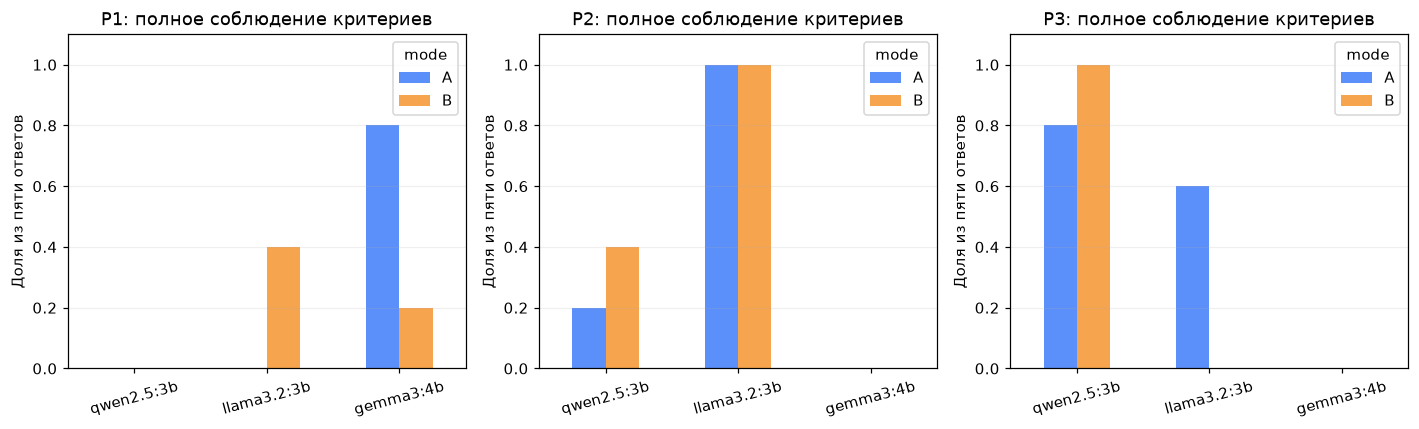

In [9]:
comparison = performance[['tokens_mean', 'latency_mean_s', 'latency_median_s', 'generation_tps_mean']].unstack('mode')
deltas = pd.DataFrame({metric + '_B_minus_A': comparison[(metric, 'B')] - comparison[(metric, 'A')]
                       for metric in ['tokens_mean', 'latency_mean_s', 'latency_median_s', 'generation_tps_mean']})
display(deltas)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for index, prompt in enumerate(['P1', 'P2', 'P3']):
    if prompt == 'P1':
        series = letters.groupby(['model', 'mode'])['criteria_ok'].mean()
    else:
        series = quality_df[quality_df['prompt'].eq(prompt)].groupby(['model', 'mode'])['semantic_and_format_ok'].mean()
    series.unstack().reindex(models).plot.bar(ax=axes[index], color=['#5b8ff9', '#f6a44d'], rot=15)
    axes[index].set(title=f'{prompt}: полное соблюдение критериев', ylabel='Доля из пяти ответов', ylim=(0, 1.1), xlabel='')
    axes[index].grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()

## 9. Выводы по этому запуску

- **Qwen:** режим B устраняет иностранные вставки в письмах и даёт пять одинаковых
  корректных JSON-объектов для извлечения. Но письма остаются короче 60 слов.
  В классификации метки правильные, а строгий JSON-формат соблюдается не всегда.
- **Llama:** в A письма часто смешивают языки; есть замена новой даты на 14 октября.
  В B русский заметно лучше, но одна иностранная вставка и речевые ошибки сохраняются.
  Классификация правильна и в корректном JSON. В извлечении B стабильно добавляет
  Markdown-обёртку, поэтому улучшение устойчивости не равно улучшению выполнения инструкции.
- **Gemma:** письма наиболее связные и сохраняют заданные факты. Подсчёт слов с временем
  как одним словом показывает пограничные нарушения длины, особенно в B.
  Классификация и извлечение по смыслу правильны после снятия Markdown и нормализации
  вариантов названия/цвета, но требование «без Markdown» систематически нарушается.
- У всех моделей отсутствующая гарантия остаётся `null` в прочитанных объектах P3.
  Ошибку Qwen с `battery_hours=null` в A нужно отличать от выдуманного значения:
  это пропуск имеющегося факта. Неполный JSON Llama — ошибка формата.
- Наблюдаемая серверная скорость основных ответов примерно 113 токенов/с у Qwen,
  106 у Llama и 85 у Gemma. Скорость A/B почти одинакова; время ответа зависит от
  длины и кэша. Значения нельзя переносить на другие ноутбуки и нагрузки.
- Настройки B не универсально лучше A: некоторые ответы стали устойчивее, а ограничения
  длины и формата всё равно нарушаются. Нет оснований выделять эффект одного из трёх
  одновременно изменённых параметров.

Ограничения: пять повторов, одни и те же простые примеры, разные дефолты семейств,
разные токенизаторы и размеры, кэшированные входы, последовательный запуск моделей,
дополнительные native-запросы, ручная оценка писем одним проверяющим. Формальная точность
на шести повторяемых обращениях не является оценкой качества на независимом наборе данных.

Это материал для итогового отчёта. Итоговый README можно оформить после проверки
критериев и обсуждения этих выводов.